<a href="https://colab.research.google.com/github/KimMinWoooo/Hands-on-ML-repo/blob/main/10_neural_nets_with_keras_2_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Chapter 10-2 – Introduction to Artificial Neural Networks with Keras**

Homework notebook

### 학번:  20192576

### 이름:  김민우

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/ageron/handson-ml2/blob/master/10_neural_nets_with_keras.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

# Setup

First, let's import a few common modules, ensure MatplotLib plots figures inline and prepare a function to save the figures. We also check that Python 3.5 or later is installed (although Python 2.x may work, it is deprecated so we strongly recommend you use Python 3 instead), as well as Scikit-Learn ≥0.20 and TensorFlow ≥2.0.

In [ ]:
# Python ≥3.7 is required
import sys
print("Python: ", sys.version_info)
assert sys.version_info >= (3, 7)

from packaging import version
import sklearn
print(sklearn.__version__)
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
except Exception:
    pass

# TensorFlow ≥2.8.0 is required
import tensorflow as tf
print("TF version: ", tf.__version__)
assert version.parse(tf.__version__) >= version.parse("2.8.0")

# GPU check
import tensorflow as tf
if tf.test.gpu_device_name():
    print('Default GPU Device: {}'.format(tf.test.gpu_device_name()))
else:
    print("Please install GPU version of TF")

# GPU check
if not "google.colab" in sys.modules:
    from tensorflow.python.client import device_lib
    print("============")
    print('Device Test')
    print("============")
    print(device_lib.list_local_devices()[0])
    print(device_lib.list_local_devices()[1])

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Where to save the figures
from pathlib import Path

IMAGES_PATH = Path() / "images" / "ann"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

Python:  sys.version_info(major=3, minor=11, micro=11, releaselevel='final', serial=0)
1.6.1
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
TF version:  2.18.0
Please install GPU version of TF


# Implementing MLPs with Keras
## Building an Image Classifier Using the Sequential API

In [ ]:
#import keras
from tensorflow import keras
keras.__version__

'3.8.0'

In [ ]:
fashion_mnist = keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

X_train, X_valid= X_train_full[:-5000] / 255., X_train_full[-5000:] / 255.
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]
X_test = X_test / 255.

tf.random.set_seed(42)
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Compiling the model

In [ ]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [ ]:
# extra code – this cell is equivalent to the previous cell
model.compile(loss=tf.keras.losses.sparse_categorical_crossentropy,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=[tf.keras.metrics.sparse_categorical_accuracy])

In [ ]:
# extra code – shows how to convert class ids to one-hot vectors
keras.utils.to_categorical([0, 5, 1, 0], num_classes=10)

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
# extra code – shows how to convert one-hot vectors to class ids
np.argmax(
    [[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
     [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
     [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
     [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],
    axis=1
)

array([0, 5, 1, 0])

### Training and evaluating the model

In [ ]:
history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 1.0127 - sparse_categorical_accuracy: 0.6730 - val_loss: 0.5099 - val_sparse_categorical_accuracy: 0.8278
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.5083 - sparse_categorical_accuracy: 0.8273 - val_loss: 0.4569 - val_sparse_categorical_accuracy: 0.8400
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.4544 - sparse_categorical_accuracy: 0.8428 - val_loss: 0.4320 - val_sparse_categorical_accuracy: 0.8474
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.4246 - sparse_categorical_accuracy: 0.8524 - val_loss: 0.4169 - val_sparse_categorical_accuracy: 0.8524
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.4032 - sparse_categorical_accuracy: 0.8600 - val_loss: 0.4056 - val_sparse_categorical_accuracy: 0.8566
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.3866 - sparse_categorical_accuracy: 0.8655 - val_loss: 0.3957 - val_sparse_categorical_accurac

In [ ]:
history.params

{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

In [ ]:
print(history.epoch)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


In [ ]:
history.history.keys()

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])

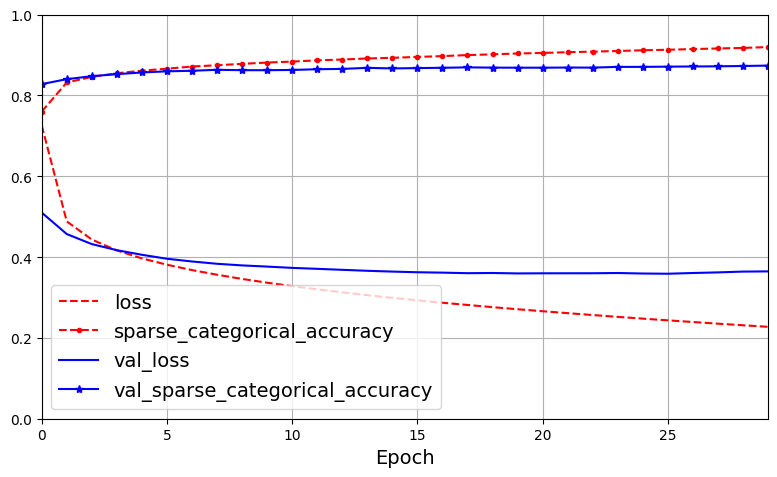

In [ ]:
import pandas as pd

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code
save_fig("keras_learning_curves_plot")  # extra code
plt.show()

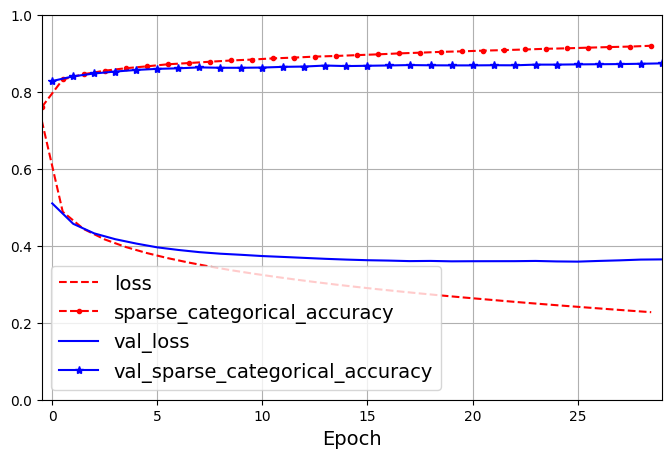

In [ ]:
# extra code – shows how to shift the training curve by -1/2 epoch
plt.figure(figsize=(8, 5))
for key, style in zip(history.history, ["r--", "r--.", "b-", "b-*"]):
    epochs = np.array(history.epoch) + (0 if key.startswith("val_") else -0.5)
    plt.plot(epochs, history.history[key], style, label=key)
plt.xlabel("Epoch")
plt.axis([-0.5, 29, 0., 1])
plt.legend(loc="lower left")
plt.grid()
plt.show()

In [ ]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3769 - sparse_categorical_accuracy: 0.8734


[0.37815916538238525, 0.8716999888420105]

### == P1. Training and evaluating the model ==
#### 1. loss, accuracy, val_loss, val_accuracy의 의미를 설명하시오
####     loss: 훈련 데이터에서 모델의 예측값과 실제값 간의 차이
####     accuracy: 훈련 데이터에서 모델의 예측이 얼마나 정확한지 나타내는 지표
####     val_loss: 검증 데이터에서의 손실 값
####     val_accuracy: 검증 데이터에서 모델의 예측 정확도

#### 2. cell 10에서 loss와 accuracy에 대해 1/2 epoch만큼 shift시킨 이유는?
####     훈련 곡선이 검증 곡선보다 약간 먼저 시작되므로, 이를 맞추기 위해 1/2 epoch만큼 훈련 곡선을 왼쪽으로 이동시키는 작업을 하여 두 곡선을 정확하게 비교할 수 있어, 모델 학습 중 발생하는 overfitting을 더 명확하게 파악 가능함

#### 3. 아래의 cell에서 Batch size를 구하는 코드를 작성하시오
####     

In [ ]:
# 3. Calculate batch size
batch_size = X_train.shape[0] // history.params['steps']
print("Batch size:", batch_size)

Batch size: 31


### Using the model to make predictions

In [ ]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.25, 0.  , 0.02, 0.  , 0.74],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [ ]:
y_pred = np.argmax(y_proba, axis=-1)
y_pred

array([9, 2, 1])

In [ ]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [ ]:
y_new = y_test[:3]
y_new

array([9, 2, 1], dtype=uint8)

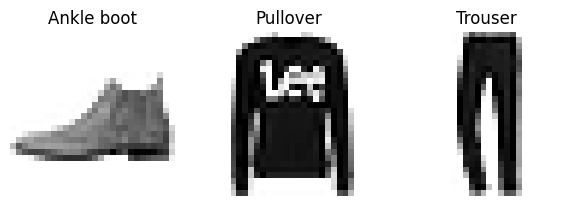

In [ ]:
plt.figure(figsize=(7.2, 2.4))
for index, image in enumerate(X_new):
    plt.subplot(1, 3, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_test[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
save_fig('fashion_mnist_images_plot', tight_layout=False)
plt.show()

In [ ]:
y1_train=keras.utils.to_categorical(y_train)
print('sparse label: ', y_train[:3]) # sparse label
print('one-hot vector label: ')
print(y1_train[:3]) # one-hot vector label

sparse label:  [9 0 0]
one-hot vector label: 
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


### Exercise 10.2  
Fashion MNIST 실습코드를 이용하여 아래에서 요구하는 hidden layer의 수와 neuron의 수를 갖는 MLP 모델을 구성하고 30 epoch 동안 학습시킨후 training loss와 test accuracy, step당 학습시간, 파라미터의 크기를 비교하시오. 모든 경우 learning curve를 그리시오.
1. (300, 300, 100)
2. (300, 100, 30)
3. (1000, 100)
4. (300, 30)
5. (100, 30)
6. 위의 실습 코드 결과와 함께 결과를 비교하고 분석하시오.

In [ ]:
# EX. 10.2

fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6653 - loss: 1.0457 - val_accuracy: 0.8194 - val_loss: 0.5315
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8256 - loss: 0.4925 - val_accuracy: 0.8472 - val_loss: 0.4460
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.8455 - loss: 0.4347 - val_accuracy: 0.8598 - val_loss: 0.4056
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8561 - loss: 0.4012 - val_accuracy: 0.8642 - val_loss: 0.3837
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8642 - loss: 0.3771 - val_accuracy: 0.8692 - val_loss: 0.3657
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8714 - loss: 0.3588 - val_accuracy: 0.8730 - val_loss: 0.3550
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8777 - loss: 0.3439 - val_accuracy: 0.8752 - val_loss: 0.3459
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.8820 - loss: 0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 300)                 │          90,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 356,912 (1.36 MB)

 Trainable params: 356,910 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

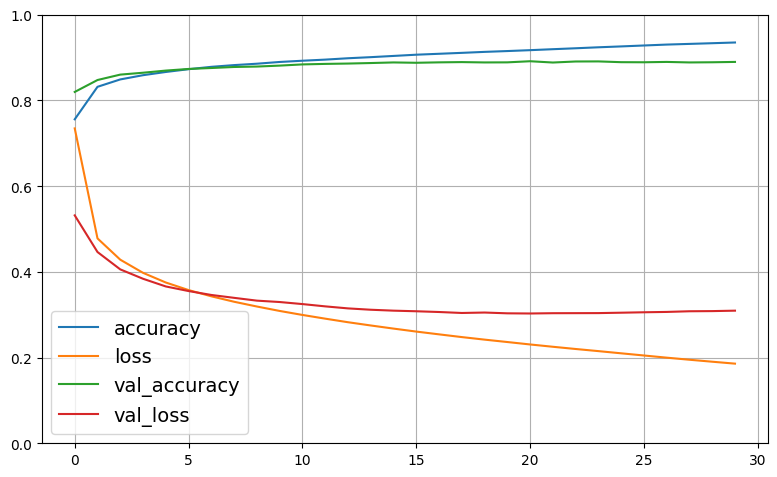

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8756 - loss: 0.3592
Test accuracy: 0.8799999952316284


In [ ]:
#1
keras.backend.clear_session()
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid))

# 학습 결과 출력
model.summary()

# 학습 곡선 그리기
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
save_fig("keras_learning_curves_plot_300_300_100")
plt.show()

# Test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)


# import pandas as pd
# pd.DataFrame(history.history).plot(figsize=(8, 5))
# plt.grid(True)
# plt.gca().set_ylim(0, 1)
# save_fig("keras_learning_curves_plot")
# plt.show()

# model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6519 - loss: 1.0677 - val_accuracy: 0.8086 - val_loss: 0.5399
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8215 - loss: 0.4995 - val_accuracy: 0.8408 - val_loss: 0.4600
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8424 - loss: 0.4435 - val_accuracy: 0.8508 - val_loss: 0.4234
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8523 - loss: 0.4096 - val_accuracy: 0.8590 - val_loss: 0.3959
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8606 - loss: 0.3856 - val_accuracy: 0.8642 - val_loss: 0.3787
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8671 - loss: 0.3667 - val_accuracy: 0.8680 - val_loss: 0.3665
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8742 - loss: 0.3509 - val_accuracy: 0.8714 - val_loss: 0.3573
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8777 - loss: 0.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 30)                  │           3,030 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             310 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 268,942 (1.03 MB)

 Trainable params: 268,940 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

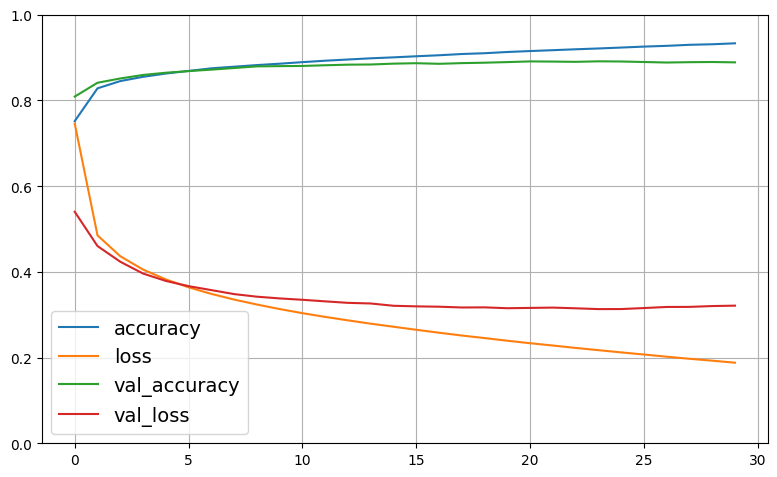

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8751 - loss: 0.3755
Test accuracy: 0.8765000104904175


In [ ]:
#2
keras.backend.clear_session()
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid))

# 학습 결과 출력
model.summary()

# 학습 곡선 그리기
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
save_fig("keras_learning_curves_plot_300_100_30")
plt.show()

# Test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7011 - loss: 0.9395 - val_accuracy: 0.8274 - val_loss: 0.5071
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.8301 - loss: 0.4866 - val_accuracy: 0.8448 - val_loss: 0.4450
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8465 - loss: 0.4364 - val_accuracy: 0.8552 - val_loss: 0.4132
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8561 - loss: 0.4069 - val_accuracy: 0.8630 - val_loss: 0.3905
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8641 - loss: 0.3854 - val_accuracy: 0.8678 - val_loss: 0.3742
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8700 - loss: 0.3686 - val_accuracy: 0.8706 - val_loss: 0.3620
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.8747 - loss: 0.3543 - val_accuracy: 0.8750 - val_loss: 0.3525
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8804 - loss: 0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1000)                │         785,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │         100,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 886,112 (3.38 MB)

 Trainable params: 886,110 (3.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

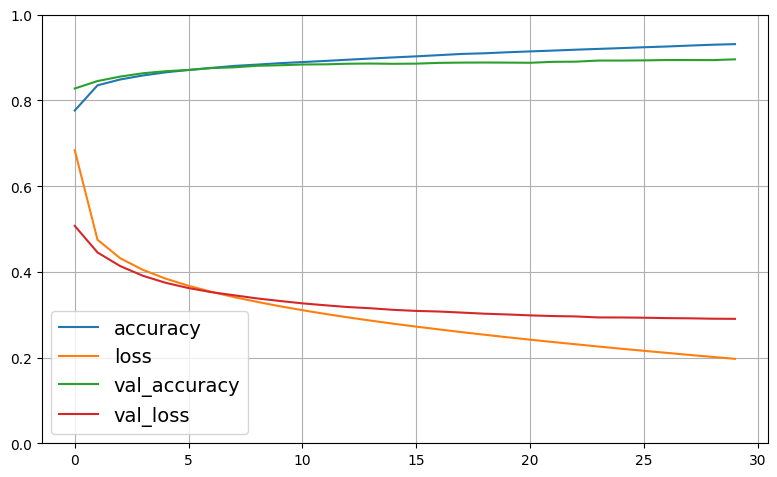

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8823 - loss: 0.3346
Test accuracy: 0.8841999769210815


In [ ]:
#3
keras.backend.clear_session()
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(1000, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid))

# 학습 결과 출력
model.summary()

# 학습 곡선 그리기
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
save_fig("keras_learning_curves_plot_1000_100")
plt.show()

# Test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)




/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6732 - loss: 0.9967 - val_accuracy: 0.8218 - val_loss: 0.5359
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8234 - loss: 0.5031 - val_accuracy: 0.8420 - val_loss: 0.4717
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8409 - loss: 0.4492 - val_accuracy: 0.8480 - val_loss: 0.4369
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8518 - loss: 0.4192 - val_accuracy: 0.8564 - val_loss: 0.4129
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8583 - loss: 0.3981 - val_accuracy: 0.8606 - val_loss: 0.3955
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8641 - loss: 0.3811 - val_accuracy: 0.8628 - val_loss: 0.3823
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8688 - loss: 0.3668 - val_accuracy: 0.8664 - val_loss: 0.3704
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8736 - loss: 0.3545 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 30)                  │           9,030 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             310 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 244,842 (956.42 KB)

 Trainable params: 244,840 (956.41 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

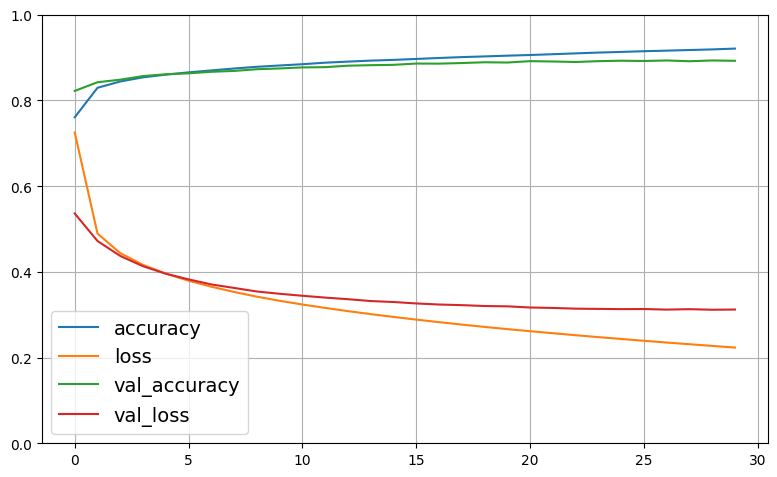

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8709 - loss: 0.3587
Test accuracy: 0.8740000128746033


In [ ]:
#4
keras.backend.clear_session()
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid))

# 학습 결과 출력
model.summary()

# 학습 곡선 그리기
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
save_fig("keras_learning_curves_plot_300_30")
plt.show()

# Test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6310 - loss: 1.1180 - val_accuracy: 0.8076 - val_loss: 0.5524
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8164 - loss: 0.5274 - val_accuracy: 0.8358 - val_loss: 0.4821
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8351 - loss: 0.4671 - val_accuracy: 0.8454 - val_loss: 0.4460
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8457 - loss: 0.4357 - val_accuracy: 0.8556 - val_loss: 0.4219
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8533 - loss: 0.4144 - val_accuracy: 0.8578 - val_loss: 0.4063
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8590 - loss: 0.3984 - val_accuracy: 0.8614 - val_loss: 0.3953
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8629 - loss: 0.3851 - val_accuracy: 0.8640 - val_loss: 0.3840
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8677 - loss: 0.3739

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 30)                  │           3,030 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             310 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 81,842 (319.70 KB)

 Trainable params: 81,840 (319.69 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

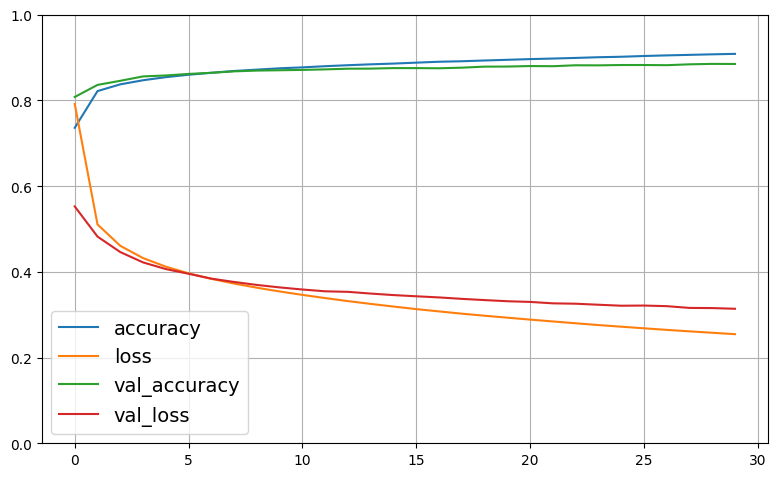

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8744 - loss: 0.3522
Test accuracy: 0.8766999840736389


In [ ]:
#5
keras.backend.clear_session()
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid))

# 학습 결과 출력
model.summary()

# 학습 곡선 그리기
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
save_fig("keras_learning_curves_plot_100_30")
plt.show()

# Test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)




#### EX10.2 6   
<!-- ![image.png](attachment:image.png) -->


파라미터 수와 학습 속도 방면 : 파라미터 수가 많을수록 모델이 더 복잡하고, 더 많은 계산이 필요하므로 학습 시간이 길어집니다. 예를 들어, (1000, 100) 모델은 886,112개의 파라미터를 갖고 있지만, (100, 30) 모델은 81,842개의 파라미터만 가지고 있어 훨씬 빠른 학습 속도를 보이고 있습니다.

정확도 방면 : 성능 측면에서 (1000, 100) 모델이 가장 좋은 테스트 정확도를 보였고, 그 뒤를 이어 (300, 300, 100) 모델이 비슷한 성능을 보였습니다. 모델이 커질수록 더 높은 정확도를 얻는 경향이 있지만, 성능의 향상 폭은 일정 시점 이후 감소할 수 있습니다. 반면, (300, 30) 모델과 (100, 30) 모델은 상대적으로 정확도가 낮습니다.

효율성 방면 : (100, 30) 모델은 가장 적은 파라미터를 가지고 있지만, 훈련 정확도와 테스트 정확도가 꽤 괜찮습니다. 이는 작은 모델이지만 효율적으로 학습할 수 있음을 보여줍니다.

학습 시간 방면 : 파라미터 수가 많을수록 학습 시간이 늘어납니다. 예를 들어, (1000, 100) 모델은 학습 시간이 약 2초로 가장 길었고, (100, 30) 모델은 1초로 가장 빠른 학습 속도를 보였습니다.

## Building a Regression MLP Using the Sequential API

Let's load, split and scale the California housing dataset (the original one, not the modified one as in chapter 2):

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42, test_size=0.1)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42, test_size=0.2)

In [ ]:
print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(14860, 8)
(3716, 8)
(2064, 8)


In [ ]:
keras.backend.clear_session()
tf.random.set_seed(42)
norm_layer = tf.keras.layers.Normalization(input_shape=X_train.shape[1:])
model = tf.keras.Sequential([
    norm_layer,
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(1)
])
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])
norm_layer.adapt(X_train)
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))
mse_test, rmse_test = model.evaluate(X_test, y_test)
X_new = X_test[:3]
y_pred = model.predict(X_new)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - RootMeanSquaredError: 1.1404 - loss: 1.3872 - val_RootMeanSquaredError: 0.6546 - val_loss: 0.4286
Epoch 2/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 0.6354 - loss: 0.4039 - val_RootMeanSquaredError: 0.6244 - val_loss: 0.3899
Epoch 3/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6046 - loss: 0.3656 - val_RootMeanSquaredError: 0.6117 - val_loss: 0.3742
Epoch 4/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - RootMeanSquaredError: 0.5915 - loss: 0.3499 - val_RootMeanSquaredError: 0.6090 - val_loss: 0.3709
Epoch 5/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5842 - loss: 0.3414 - val_RootMeanSquaredError: 0.5998 - val_loss: 0.3598
Epoch 6/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - RootMeanSquaredError: 0.5749 - loss: 0.3305 - val_RootMeanSquaredError: 0.5818 - val_loss: 0.3385
Epoch 7/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5661 - los

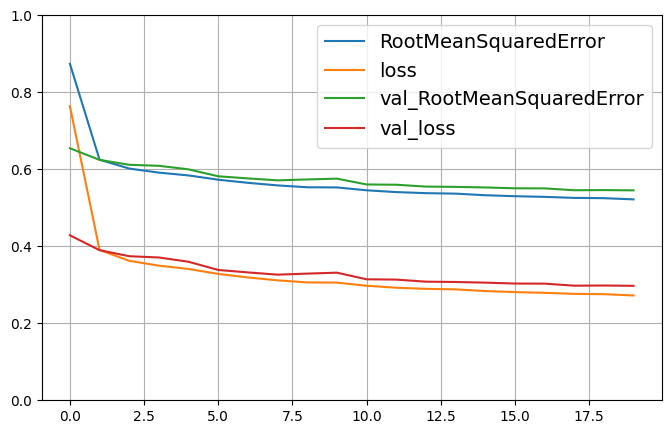

In [ ]:
#plt.plot(pd.DataFrame(history.history))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [ ]:
rmse_test

0.5568461418151855

In [ ]:
y_pred

array([[0.5661338],
       [1.1438783],
       [4.446459 ]], dtype=float32)

### == P2. Building a Regression MLP Using the Sequential API ==
#### 학습결과와 rmse_test를 비교하여 학습결과를 분석하시오
#### Answer:
-

## Building Complex Models Using the Functional API

Not all neural network models are simply sequential. Some may have complex topologies. Some may have multiple inputs and/or multiple outputs. For example, a Wide & Deep neural network (see [paper](https://ai.google/research/pubs/pub45413)) connects all or part of the inputs directly to the output layer.

In [ ]:
# extra code – reset the name counters and make the code reproducible
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [ ]:
normalization_layer = tf.keras.layers.Normalization()
hidden_layer1 = tf.keras.layers.Dense(30, activation="relu")
hidden_layer2 = tf.keras.layers.Dense(30, activation="relu")
concat_layer = tf.keras.layers.Concatenate()
output_layer = tf.keras.layers.Dense(1)

input_ = tf.keras.layers.Input(shape=X_train.shape[1:])
normalized = normalization_layer(input_)
hidden1 = hidden_layer1(normalized)
hidden2 = hidden_layer2(hidden1)
concat = concat_layer([normalized, hidden2])
output = output_layer(concat)

model1 = tf.keras.Model(inputs=[input_], outputs=[output])

In [ ]:
model1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 8)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 8)              │             17 │ input_layer[0][0]      │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 30)             │            270 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 30)             │            930 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 38)             │              0 │ normalization[0][0],   │
│                           │                        │                │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 1)              │             39 │ concatenate[0][0]      │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 1,256 (4.91 KB)

 Trainable params: 1,239 (4.84 KB)

 Non-trainable params: 17 (72.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model1.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])
normalization_layer.adapt(X_train)
history = model1.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))
mse_test = model1.evaluate(X_test, y_test)
y_pred = model1.predict(X_new)
print("y_pred: \n", y_pred )

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 8))
  warnings.warn(msg)


465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - RootMeanSquaredError: 1.5136 - loss: 2.4457 - val_RootMeanSquaredError: 0.7009 - val_loss: 0.4913
Epoch 2/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6840 - loss: 0.4686 - val_RootMeanSquaredError: 0.6486 - val_loss: 0.4207
Epoch 3/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - RootMeanSquaredError: 0.6354 - loss: 0.4039 - val_RootMeanSquaredError: 0.6349 - val_loss: 0.4031
Epoch 4/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 0.6162 - loss: 0.3798 - val_RootMeanSquaredError: 0.6222 - val_loss: 0.3871
Epoch 5/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - RootMeanSquaredError: 0.6060 - loss: 0.3673 - val_RootMeanSquaredError: 0.6150 - val_loss: 0.3782
Epoch 6/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 0.5962 - loss: 0.3555 - val_RootMeanSquaredError: 0.6105 - val_loss: 0.3728
Epoch 7/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5946 - loss: 0.3536 -

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(3, 8))
  warnings.warn(msg)


What if you want to send different subsets of input features through the wide or deep paths? We will send 5 features (features 0 to 4), and 6 through the deep path (features 2 to 7). Note that 3 features will go through both (features 2, 3 and 4).

In [ ]:
tf.random.set_seed(42)

In [ ]:
input_wide = tf.keras.layers.Input(shape=[5])  # features 0 to 4
input_deep = tf.keras.layers.Input(shape=[6])  # features 2 to 7
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)
concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)
model2 = tf.keras.Model(inputs=[input_wide, input_deep], outputs=[output])
model2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 6)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization_2           │ (None, 6)              │             13 │ input_layer_2[0][0]    │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 5)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 30)             │            210 │ normalization_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization_1           │ (None, 5)              │             11 │ input_layer_1[0][0]    │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 30)             │            930 │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 35)             │              0 │ normalization_1[0][0], │
│ (Concatenate)             │                        │                │ dense_4[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 1)              │             36 │ concatenate_1[0][0]    │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 1,200 (4.70 KB)

 Trainable params: 1,176 (4.59 KB)

 Non-trainable params: 24 (104.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model2.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

X_train_wide, X_train_deep = X_train[:, :5], X_train[:, 2:]
X_valid_wide, X_valid_deep = X_valid[:, :5], X_valid[:, 2:]
X_test_wide, X_test_deep = X_test[:, :5], X_test[:, 2:]
X_new_wide, X_new_deep = X_test_wide[:3], X_test_deep[:3]

norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)
history = model2.fit((X_train_wide, X_train_deep), y_train, epochs=20,
                    validation_data=((X_valid_wide, X_valid_deep), y_valid))
mse_test = model2.evaluate((X_test_wide, X_test_deep), y_test)
y_pred = model2.predict((X_new_wide, X_new_deep))
print("y_pred: \n", y_pred )

Epoch 1/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - RootMeanSquaredError: 1.6984 - loss: 3.0206 - val_RootMeanSquaredError: 0.7944 - val_loss: 0.6310
Epoch 2/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.7533 - loss: 0.5681 - val_RootMeanSquaredError: 0.6914 - val_loss: 0.4781
Epoch 3/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - RootMeanSquaredError: 0.6676 - loss: 0.4458 - val_RootMeanSquaredError: 0.6628 - val_loss: 0.4393
Epoch 4/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 0.6364 - loss: 0.4051 - val_RootMeanSquaredError: 0.6642 - val_loss: 0.4412
Epoch 5/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6305 - loss: 0.3977 - val_RootMeanSquaredError: 0.6401 - val_loss: 0.4097
Epoch 6/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: 0.6097 - loss: 0.3718 - val_RootMeanSquaredError: 0.6359 - val_loss: 0.4043
Epoch 7/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 0.6054 - los

Adding an auxiliary output for regularization:

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [ ]:
input_wide = tf.keras.layers.Input(shape=[5])  # features 0 to 4
input_deep = tf.keras.layers.Input(shape=[6])  # features 2 to 7
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)
concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)
aux_output = tf.keras.layers.Dense(1)(hidden2)
model3 = tf.keras.Model(inputs=[input_wide, input_deep],
                       outputs=[output, aux_output])
model3.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 6)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization_1           │ (None, 6)              │             13 │ input_layer_1[0][0]    │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer (InputLayer)  │ (None, 5)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 30)             │            210 │ normalization_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 5)              │             11 │ input_layer[0][0]      │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 30)             │            930 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 35)             │              0 │ normalization[0][0],   │
│                           │                        │                │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 1)              │             36 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 1)              │             31 │ dense_1[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 1,231 (4.82 KB)

 Trainable params: 1,207 (4.71 KB)

 Non-trainable params: 24 (104.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model3.compile(loss=("mse", "mse"), loss_weights=(0.9, 0.1), optimizer=optimizer,
              metrics=["RootMeanSquaredError", "RootMeanSquaredError"])
# Higher version
# model3.compile(loss=("mse", "mse"), loss_weights=(0.9, 0.1), optimizer=optimizer,
#              metrics=["RootMeanSquaredError", "RootMeanSquaredError"])

In [ ]:
norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)
history = model3.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=20,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid))
)

Epoch 1/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - dense_2_RootMeanSquaredError: 1.3901 - dense_2_loss: 2.0043 - dense_3_RootMeanSquaredError: 1.6798 - dense_3_loss: 2.8981 - loss: 2.0937 - val_dense_2_RootMeanSquaredError: 0.7821 - val_dense_2_loss: 0.6109 - val_dense_3_RootMeanSquaredError: 0.9533 - val_dense_3_loss: 0.9061 - val_loss: 0.6415
Epoch 2/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - dense_2_RootMeanSquaredError: 0.7370 - dense_2_loss: 0.5438 - dense_3_RootMeanSquaredError: 0.9278 - dense_3_loss: 0.8652 - loss: 0.5760 - val_dense_2_RootMeanSquaredError: 0.6920 - val_dense_2_loss: 0.4783 - val_dense_3_RootMeanSquaredError: 0.7966 - val_dense_3_loss: 0.6322 - val_loss: 0.4944
Epoch 3/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - dense_2_RootMeanSquaredError: 0.6637 - dense_2_loss: 0.4405 - dense_3_RootMeanSquaredError: 0.7862 - dense_3_loss: 0.6184 - loss: 0.4583 - val_dense_2_RootMeanSquaredError: 0.6659 - val_dense_2_loss: 0.4428 - val_dense_3_RootMeanSquaredError: 0.7

In [ ]:
eval_results = model3.evaluate((X_test_wide, X_test_deep), (y_test, y_test))
weighted_sum_of_losses, main_loss, aux_loss, main_rmse, aux_rmse = eval_results
#Higher version
#weighted_sum_of_losses, main_loss, aux_loss = eval_results[:3]

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - dense_2_RootMeanSquaredError: 0.5705 - dense_2_loss: 0.3258 - dense_3_RootMeanSquaredError: 0.6294 - dense_3_loss: 0.3963 - loss: 0.3329


In [ ]:
y_pred_main, y_pred_aux = model3.predict((X_new_wide, X_new_deep))
print("y_pred_main: \n", y_pred_main)
print("y_pred_aux: \n", y_pred_aux)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
y_pred_main: 
 [[0.42823797]
 [1.2984834 ]
 [3.6772263 ]]
y_pred_aux: 
 [[0.627687 ]
 [1.3290114]
 [3.4176285]]


In [ ]:
y_pred_tuple = model3.predict((X_new_wide, X_new_deep))
y_pred = dict(zip(model3.output_names, y_pred_tuple))
print(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
{'dense_2': array([[0.42823797],
       [1.2984834 ],
       [3.6772263 ]], dtype=float32), 'dense_3': array([[0.627687 ],
       [1.3290114],
       [3.4176285]], dtype=float32)}


### == P3. Building Complex Models Using the Functional API ==
#### 학습결과와 rmse_test를 비교하여 학습결과를 분석하시오
#### Answer:
-

### Using the Subclassing API to Build Dynamic Models

In [ ]:
class WideAndDeepModel(tf.keras.Model):
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs)  # needed to support naming the model
        self.norm_layer_wide = tf.keras.layers.Normalization()
        self.norm_layer_deep = tf.keras.layers.Normalization()
        self.hidden1 = tf.keras.layers.Dense(units, activation=activation)
        self.hidden2 = tf.keras.layers.Dense(units, activation=activation)
        self.main_output = tf.keras.layers.Dense(1)
        self.aux_output = tf.keras.layers.Dense(1)

    def call(self, inputs):
        input_wide, input_deep = inputs
        norm_wide = self.norm_layer_wide(input_wide)
        norm_deep = self.norm_layer_deep(input_deep)
        hidden1 = self.hidden1(norm_deep)
        hidden2 = self.hidden2(hidden1)
        concat = tf.keras.layers.concatenate([norm_wide, hidden2])
        output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return output, aux_output

tf.random.set_seed(42)  # extra code – just for reproducibility
model = WideAndDeepModel(30, activation="relu", name="my_cool_model")

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss=["mse", "mse"], loss_weights=[0.9, 0.1], optimizer=optimizer,
              metrics=[["RootMeanSquaredError"], ["RootMeanSquaredError"]])
model.norm_layer_wide.adapt(X_train_wide)
model.norm_layer_deep.adapt(X_train_deep)
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=10,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)))
print("\nEvaluating...")
eval_results = model.evaluate((X_test_wide, X_test_deep), (y_test, y_test))
y_pred_main, y_pred_aux = model.predict((X_new_wide, X_new_deep))
print(eval_results)
weighted_sum_of_rmse = eval_results[3]*0.9 + eval_results[4]*0.1
#Higher version
#weighted_sum_of_rmse = eval_results[1]*0.9 + eval_results[5]*0.1
print("weighted_sum_of_rmses: ", weighted_sum_of_rmse)

Epoch 1/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - RootMeanSquaredError: 1.6100 - RootMeanSquaredError_1: 1.7014 - loss: 2.7393 - mse_loss: 2.9893 - val_RootMeanSquaredError: 0.8274 - val_RootMeanSquaredError_1: 0.9108 - val_loss: 0.6991 - val_mse_loss: 0.8275
Epoch 2/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 0.7871 - RootMeanSquaredError_1: 0.8923 - loss: 0.6379 - mse_loss: 0.7988 - val_RootMeanSquaredError: 0.7278 - val_RootMeanSquaredError_1: 0.7998 - val_loss: 0.5407 - val_mse_loss: 0.6384
Epoch 3/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.7001 - RootMeanSquaredError_1: 0.7850 - loss: 0.5029 - mse_loss: 0.6164 - val_RootMeanSquaredError: 0.6891 - val_RootMeanSquaredError_1: 0.7645 - val_loss: 0.4858 - val_mse_loss: 0.5829
Epoch 4/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - RootMeanSquaredError: 0.6532 - RootMeanSquaredError_1: 0.7519 - loss: 0.4406 - mse_loss: 0.5654 - val_RootMeanSquaredError: 0.6508 - val_RootMeanSquaredEr

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
[0.37316104769706726, 0.604459822177887, 0.604459822177887, 0.4445660412311554, 0.4445660412311554, 0.6657821536064148]
weighted_sum_of_rmses:  0.4445660412311554


In [ ]:
print("y_pred_main: \n", y_pred_main)
print("y_pred_aux: \n", y_pred_aux)

y_pred_main: 
 [[0.43412277]
 [1.4716002 ]
 [3.5156457 ]]
y_pred_aux: 
 [[0.59472495]
 [1.6218333 ]
 [3.2291348 ]]


### Exercise 10.3  

Refer the previous cells.
Plot the loss curves and obtain weighted rmse_test values for the following learning rates for Adam optimizer and epochs
1) 2e-3, epoch = 5  
2) 2e-3, epoch = 10  
3) 1e-3, epoch = 10  
4) 5e-4, epoch = 10  
5) 5e-4, epoch = 20     
6) Discuss the results for the above hyperparameters.

In [61]:
# Ex.10.3
tf.keras.backend.clear_session()
tf.random.set_seed(42)
model1 = WideAndDeepModel(30)
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-3)


Exception ignored in: <function _xla_gc_callback at 0x7bba171249a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/jax/_src/lib/__init__.py", line 96, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


#### Ex. 10.3 6